<a href="https://colab.research.google.com/github/cd3004/CNN-Lab-Assignment/blob/main/24cd3004_CNN_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Task 1: Environment Setup & Data Pipeline

## Problem 1: Environment Verification

In [4]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib
import random

# Setting seeds
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Versions
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)

# GPU check
print("GPU:", tf.config.list_physical_devices('GPU'))

# Explanation:
# CPU is slower because it performs sequential computation.
# GPU is faster due to parallel processing using multiple cores.
# Seeds ensure reproducibility of random operations.

TensorFlow: 2.19.0
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
## Problem 2: Dataset Exploration


In [6]:
from tensorflow.keras.datasets import mnist, cifar10
import numpy as np

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

print("MNIST Train Shape:", x_train_mnist.shape)
print("MNIST Test Shape:", x_test_mnist.shape)

print("CIFAR Train Shape:", x_train_cifar.shape)
print("CIFAR Test Shape:", x_test_cifar.shape)

print("MNIST dtype:", x_train_mnist.dtype, "Range:", x_train_mnist.min(), "-", x_train_mnist.max())
print("CIFAR dtype:", x_train_cifar.dtype, "Range:", x_train_cifar.min(), "-", x_train_cifar.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR Train Shape: (50000, 32, 32, 3)
CIFAR Test Shape: (10000, 32, 32, 3)
MNIST dtype: uint8 Range: 0 - 255
CIFAR dtype: uint8 Range: 0 - 255


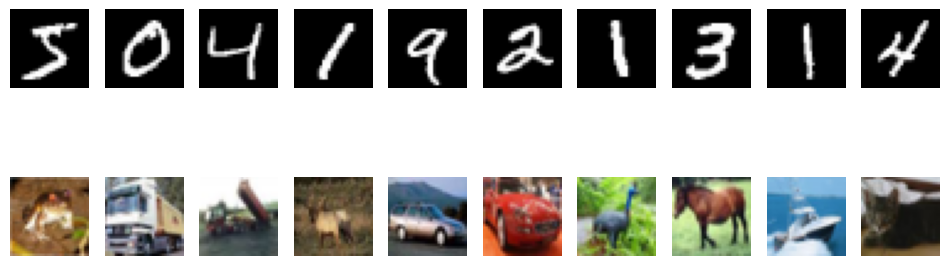

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(x_train_mnist[i], cmap='gray')
    plt.axis('off')

    plt.subplot(2,10,i+11)
    plt.imshow(x_train_cifar[i])
    plt.axis('off')

plt.savefig("dataset_samples.png")
plt.show()

### Answer:

MNIST training data shape is (60000, 28, 28) and test data is (10000, 28, 28).
CIFAR-10 training data shape is (50000, 32, 32, 3) and test data is (10000, 32, 32, 3).
The data type is uint8 and values range from 0 to 255.
The dataset is approximately balanced across classes.

In [9]:
## Problem 3: Preprocessing Pipeline


In [10]:
from tensorflow.keras.utils import to_categorical

# BEFORE
print("Before Shape:", x_train_mnist.shape)
print("Before Range:", x_train_mnist.min(), "-", x_train_mnist.max())

# Normalize
x_train_mnist = x_train_mnist / 255.0
x_test_mnist = x_test_mnist / 255.0

# Reshape
x_train_mnist = x_train_mnist.reshape(-1,28,28,1)
x_test_mnist = x_test_mnist.reshape(-1,28,28,1)

# One-hot encoding
y_train_mnist = to_categorical(y_train_mnist, 10)
y_test_mnist = to_categorical(y_test_mnist, 10)

# AFTER
print("After Shape:", x_train_mnist.shape)
print("After Range:", x_train_mnist.min(), "-", x_train_mnist.max())

Before Shape: (60000, 28, 28)
Before Range: 0 - 255
After Shape: (60000, 28, 28, 1)
After Range: 0.0 - 1.0


### Answer:

The preprocessing pipeline normalizes pixel values to [0,1], reshapes the images to include a channel dimension, and converts labels into one-hot encoded vectors for classification.

In [11]:
## Problem 4: Data Augmentation Pipeline

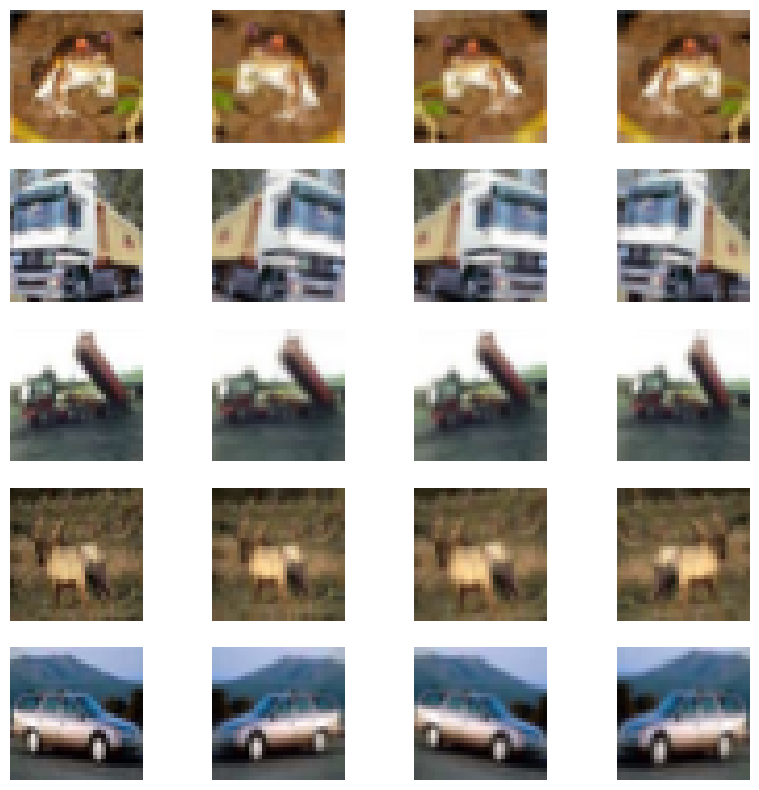

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

sample = x_train_cifar[:5]

plt.figure(figsize=(10,10))

for i in range(5):
    plt.subplot(5,4,i*4+1)
    plt.imshow(sample[i])
    plt.axis('off')

    aug = datagen.flow(sample[i:i+1], batch_size=1)

    for j in range(3):
        img = next(aug)[0]
        img = img / np.max(img)   # normalize to 0–1
        plt.subplot(5,4,i*4+j+2)
        plt.imshow(img)
        plt.axis('off')

plt.savefig("augmentation_demo.png")
plt.show()

### Answer:

Data augmentation is applied only to the training set to improve model generalization.
Applying it to validation or test data would distort evaluation results and lead to incorrect performance measurement.

## Analysis Questions

Q1: Channel represents number of color channels. Grayscale images have 1 channel, RGB images have 3 channels.

Q2: For large images, batch loading and data generators help reduce memory usage.

Q3: Using test statistics causes data leakage and leads to biased evaluation.

In [15]:
# Task 2: Building a CNN from Scratch

## Problem 1: Manual 2D Convolution

In [16]:
import numpy as np

def conv2d(image, kernel, stride=1, padding=0):
    image_padded = np.pad(image, padding, mode='constant')

    k = kernel.shape[0]
    output_size = (image_padded.shape[0] - k)//stride + 1

    output = np.zeros((output_size, output_size))

    for i in range(output_size):
        for j in range(output_size):
            region = image_padded[i:i+k, j:j+k]
            output[i,j] = np.sum(region * kernel)

    return output


# Test image
image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

# Sobel kernel
kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

output = conv2d(image, kernel)

print("Output:\n", output)
print("Output Shape:", output.shape)

Output:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output Shape: (3, 3)


### Answer:

The convolution operation applies a kernel over the image using element-wise multiplication and summation, producing a feature map. The output shape matches the expected dimensions calculated using the convolution formula.

In [17]:
## Problem 2: Output Size Derivation

### Answer:

(a) Output = (28 - 5 + 0)/1 + 1 = 24 → 24×24  
(b) Output = (28 - 3 + 2)/1 + 1 = 28 → 28×28  
(c) Output = (32 - 3 + 0)/2 + 1 = 15 → 15×15  
(d) First layer: 32×32 → second layer: (32 - 3)/1 + 1 = 30 → 30×30

In [19]:
## Problem 3: Implement LeNet-5


In [21]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Conv2D(16, (5,5), activation='tanh'),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Flatten(),
    layers.Dense(120, activation='tanh'),
    layers.Dense(84, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

### Answer:

LeNet-5 uses convolution and pooling layers to extract features followed by fully connected layers for classification. Average pooling was used earlier, but modern architectures prefer max pooling for better feature selection.

In [22]:
## Problem 4: Custom CNN for CIFAR-10

In [23]:
from tensorflow.keras import layers, models

model_cifar = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_cifar.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,042 (890.79 KB)

 Trainable params: 227,594 (889.04 KB)

 Non-trainable params: 448 (1.75 KB)

### Answer:

The custom CNN consists of three convolutional blocks with batch normalization and pooling, followed by dense layers. Dropout is used to reduce overfitting, and the architecture balances complexity and performance.

## Analysis Questions

Q1: Two 3×3 layers use fewer parameters than one 5×5 and introduce more non-linearity.

Q2: Batch Normalization stabilizes training and speeds convergence. It is placed before activation.

Q3: GlobalAveragePooling reduces parameters compared to Flatten and preserves spatial information better.